In [ ]:
import pandas as pd

df = pd.read_csv('/Users/dylantoplas/Documents/ds4420/DS4420Project/bonds_dashboards/fred_md.csv')
df

In [240]:
import requests, pprint, pandas as pd

fields = 'comp_tendered,comp_bid_decimals,comp_accepted,max_comp_award'
date_b = "1979-11-15"
date_e = "2025-11-25"

api_url = f'https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/auctions_query?' \
f'field={fields}&' \
f'filter=record_date:gte:{date_b},record_date:lte:{date_e} &' \
'page[size]=10000'

response = requests.get(api_url)

# Check the status code (200 indicates success)
print(f"Status Code: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    
    # The actual data is typically in data['data']
    a_df = pd.DataFrame(data['data'])
    
    print(f"Shape: {a_df.shape}")
    print(f"\nColumns: {a_df.columns.tolist()}")
    # print(f"\nFirst few rows:")
    # print(a_df.head())
    print(f"\nNull counts:")
    print(a_df.isnull().sum())
else:
    print(f"Error: {response.text}")


Status Code: 200
Shape: (10000, 113)

Columns: ['record_date', 'cusip', 'security_type', 'security_term', 'auction_date', 'issue_date', 'maturity_date', 'price_per100', 'accrued_int_per100', 'accrued_int_per1000', 'adj_accrued_int_per1000', 'adj_price', 'allocation_pctage', 'allocation_pctage_decimals', 'announcemtd_cusip', 'announcemt_date', 'auction_format', 'avg_med_discnt_rate', 'avg_med_investment_rate', 'avg_med_price', 'avg_med_discnt_margin', 'avg_med_yield', 'back_dated', 'back_dated_date', 'bid_to_cover_ratio', 'callable', 'call_date', 'called_date', 'cash_management_bill_cmb', 'closing_time_comp', 'closing_time_noncomp', 'comp_accepted', 'comp_bid_decimals', 'comp_tendered', 'comp_tenders_accepted', 'corpus_cusip', 'cpi_base_reference_period', 'currently_outstanding', 'dated_date', 'direct_bidder_accepted', 'direct_bidder_tendered', 'est_pub_held_mat_by_type_amt', 'fima_included', 'fima_noncomp_accepted', 'fima_noncomp_tendered', 'first_int_period', 'first_int_payment_date',

In [ ]:
a_df = a_df.replace("null", pd.NA)

cols_with_na = a_df.columns[a_df.isna().sum() == 3190].tolist()
cols_with_file = a_df.columns[a_df.columns.str.contains('file')].tolist()
noncomp = a_df.columns[a_df.columns.str.contains('noncomp')].tolist()

a_df = a_df.drop(
    cols_with_na+cols_with_file+noncomp, axis=1
)

a_df

In [ ]:
a_df['int_rate']

In [ ]:
cols_wo_na = a_df.columns[a_df.isna().sum() == 0].tolist()
cols_wo_na

cols_with_file = a_df.columns[a_df.columns.str.contains('non')].tolist()
a_df = a_df.drop(
    cols_with_file, axis=1
)

a_df

In [ ]:
maturity_buckets = {
    'ultra_short': ['4-Week', '6-Week', '8-Week', '13-Week', '17-Week', '26-Week', '52-Week'],
    'short': ['2-Year', '3-Year'],
    'medium': ['5-Year', '7-Year'],
    'long': ['10-Year', '20-Year', '30-Year']
}

def get_maturity_bucket(term):
    for bucket, terms in maturity_buckets.items():
        if term in terms:
            return bucket
    return 'other'

a_df['maturity_bucket'] = a_df['security_term'].apply(get_maturity_bucket)

a_df.head()

In [ ]:
a_df.groupby('maturity_bucket').count()


In [ ]:
import pandas as pd
import re

def parse_maturity_term(term_str):
    """
    Parse terms like '9-Year 10-Month' or '70-Day' and return total years
    """
    if pd.isna(term_str):
        return None
    
    term = str(term_str)
    years = 0
    months = 0
    days = 0
    
    # Extract years
    year_match = re.search(r'(\d+)-Year', term)
    if year_match:
        years = int(year_match.group(1))
    
    # Extract months
    month_match = re.search(r'(\d+)-Month', term)
    if month_match:
        months = int(month_match.group(1))
    
    # Extract days
    day_match = re.search(r'(\d+)-Day', term)
    if day_match:
        days = int(day_match.group(1))
    
    # Extract weeks
    week_match = re.search(r'(\d+)-Week', term)
    if week_match:
        days = int(week_match.group(1)) * 7
    
    # Convert to total years
    total_years = years + (months / 12) + (days / 365.25)
    return total_years

# Apply to your dataframe
a_df['years_to_maturity'] = a_df['security_term'].apply(parse_maturity_term)

# Now classify based on parsed years
def classify_maturity(years):
    if pd.isna(years):
        return 'unknown'
    elif years < 1:
        return 'bills'      # < 1 year (Bills)
    elif years < 3:
        return 'short'      # 1-3 years (treat as 2Y)
    elif years <= 7:
        return 'medium'     # 3-7 years (treat as 5Y or 7Y)
    else:
        return 'long'       # 7+ years (treat as 10Y+)

a_df['maturity_bucket'] = a_df['years_to_maturity'].apply(classify_maturity)
print(a_df['maturity_bucket'].value_counts())

In [ ]:
a_df.groupby('maturity_bucket').count()

In [ ]:
# a_df['record_date'] = pd.to_datetime(a_df['record_date'])
# a_df['record_date'] = a_df['record_date'].dt.to_period('M')
a_df['record_date'].dtype


In [ ]:
critical_features = [
    'record_date',           
    'maturity_bucket',        
    'years_to_maturity',           
    
    # Demand/Supply Metrics
    'bid_to_cover_ratio',     # KEY demand indicator
    'offering_amt',           # Supply pressure
    'total_accepted',         # Actual issuance
    'total_tendered',         # Total demand
    
    # Competitive Bidding (Price Discovery)
    'comp_accepted',          # Smart money demand
    'comp_tendered',          # Smart money bids
    'primary_dealer_accepted', # Dealer positioning
    'primary_dealer_tendered', 
    'indirect_bidder_accepted', # Foreign demand (big signal!)
    'indirect_bidder_tendered',
    'direct_bidder_accepted',   # Domestic institutions
    'direct_bidder_tendered',
]

a_df = a_df[critical_features]

In [ ]:
numeric_cols = [
    'bid_to_cover_ratio',    
    'offering_amt',          
    'total_accepted',         
    'total_tendered', 
    'comp_accepted',         
    'comp_tendered',          
    'primary_dealer_accepted',
    'primary_dealer_tendered', 
    'indirect_bidder_accepted', 
    'indirect_bidder_tendered',
    'direct_bidder_accepted',  
    'direct_bidder_tendered',]

a_df[numeric_cols] = a_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Check for any conversion issues
print("Null counts after conversion:")
print(a_df[numeric_cols].isnull().sum())

# Check data types
print("\nData types:")
print(a_df[numeric_cols].dtypes)

In [ ]:
a_df['record_date'] = a_df['record_date'].dt.to_timestamp()

In [ ]:
a_df['record_date'] = pd.to_datetime(a_df['record_date']).dt.to_period('M')
dff = a_df.groupby(['maturity_bucket', 'record_date'])[numeric_cols].mean().reset_index()
agg_df = a_df.groupby(['maturity_bucket', 'record_date'])[numeric_cols].agg('mean')
dff

In [ ]:
from collections import Counter
Counter(dff.maturity_bucket)

In [ ]:
#dff = dff.rename_axis(['maturity_bucket', 'record_date'])

# move maturity_bucket from index into columns
dff_wide = agg_df.unstack('maturity_bucket')  # index: record_date
# columns are now a MultiIndex: (metric, maturity_bucket)

# flatten column names: years_to_maturity_bills, ...
dff_wide.columns = [
    f"{metric}_{bucket}" for metric, bucket in dff_wide.columns
]
dff_wide

In [ ]:
auction_features = pd.DataFrame({
    # Demand strength
    'bid_cover_bills': dff_wide['bid_to_cover_ratio_bills'],
    'bid_cover_long': dff_wide['bid_to_cover_ratio_long'],
    
    # Foreign demand (KEY signal!)
    'foreign_pct_bills': (
        dff_wide['indirect_bidder_accepted_bills'] / 
        dff_wide['comp_accepted_bills']
    ),
    'foreign_pct_long': (
        dff_wide['indirect_bidder_accepted_long'] / 
        dff_wide['comp_accepted_long']
    ),
    
    # Dealer positioning
    'dealer_pct_bills': (
        dff_wide['primary_dealer_accepted_bills'] / 
        dff_wide['comp_accepted_bills']
    ),
    'dealer_pct_long': (
        dff_wide['primary_dealer_accepted_long'] / 
        dff_wide['comp_accepted_long']
    ),
    
    # Supply pressure (relative to recent average)
    'offering_bills_ma_ratio': (
        dff_wide['offering_amt_bills'] / 
        dff_wide['offering_amt_bills'].rolling(6).mean()
    ),
})

In [ ]:
auction_features

In [ ]:
auction_features = auction_features.reset_index()
auction_features['record_date'].dtype

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your pandas DataFrame
correlation_matrix = auction_features.iloc[:,1:].corr()
plt.figure(figsize=(16, 6)) # Optional: Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [193]:
# # Load FRED-MD
df = pd.read_csv('/Users/dylantoplas/Documents/ds4420/DS4420Project/bonds_dashboards/fred_md.csv')
df = df.iloc[1:].reset_index(drop=True)
df['sasdate'] = pd.to_datetime(df['sasdate']).dt.to_period('M')
df


,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,1959-01,2583.560,2426.0,15.188,2.766768e+05,17689.23968,21.9616,23.3868,22.2620,31.6664,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
1,1959-02,2593.596,2434.8,15.346,2.787140e+05,17819.01912,22.3917,23.7024,22.4549,31.8987,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
2,1959-03,2610.396,2452.7,15.491,2.777753e+05,17967.91336,22.7142,23.8459,22.5651,31.8987,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
3,1959-04,2627.446,2470.0,15.435,2.833627e+05,17978.97983,23.1981,24.1903,22.8957,32.4019,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
4,1959-05,2642.720,2486.4,15.622,2.853072e+05,18119.82573,23.5476,24.3911,23.1161,32.5567,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.00,12646.00,80.7315,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,2025-04,20698.762,16739.9,123.748,1.555663e+06,721789.00000,103.6224,101.3671,101.1112,101.6979,...,119.658,131.767,32.22,36.96,28.78,52.2,554180.13,940362.47,5500.0706,32.5116
796,2025-05,20581.743,16703.7,123.575,1.550522e+06,716101.00000,103.6570,101.4038,101.1856,101.5808,...,119.780,132.071,32.31,37.08,28.87,52.2,551829.26,938763.49,5526.3170,20.3620
797,2025-06,20575.971,16664.7,123.894,1.556845e+06,723033.00000,104.2115,101.7271,101.5445,101.9628,...,120.208,132.386,32.40,37.23,28.94,60.7,549682.41,937344.92,5555.2136,18.3246
798,2025-07,20625.729,16718.9,124.370,1.565742e+06,727414.00000,103.8194,101.4573,101.4961,101.7345,...,120.036,132.778,32.47,37.28,29.01,61.7,547389.12,934567.19,5585.9624,16.4718


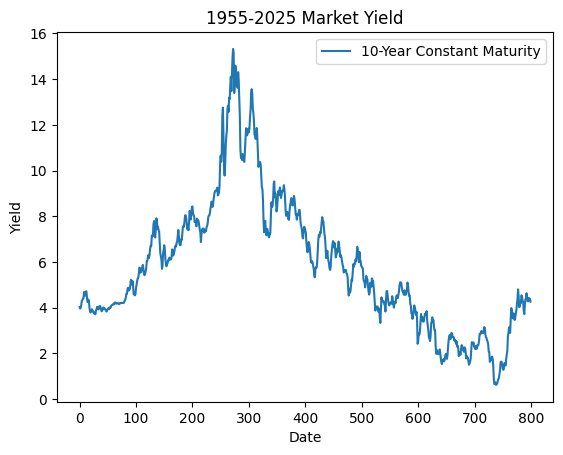

In [234]:
plt.plot(df['GS10'], label='10-Year Constant Maturity')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.legend()
plt.title('1955-2025 Market Yield')
plt.show()

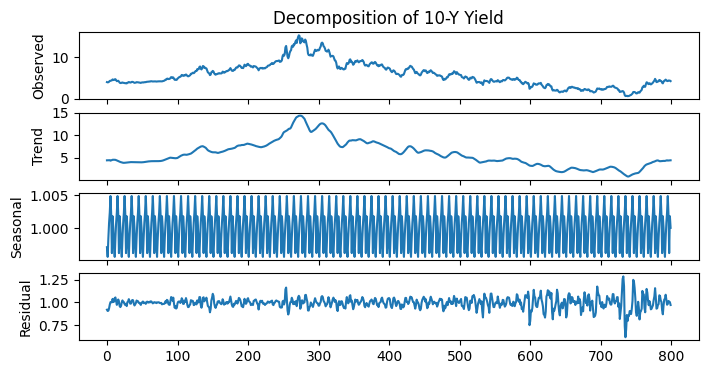

In [198]:
# Checking out the decompositions
from statsmodels.tsa.seasonal import seasonal_decompose

# setting the period makes the assumption that the seasonal trend should happen every "period" units (e.g. 10 years, or 5 days)
# can change model='multiplicative' to see if there's a change in seasonal trend
decomp1 = seasonal_decompose(df['GS10'], period=10, model='multiplicative', extrapolate_trend='freq')

fig, ax = plt.subplots(ncols=1, nrows=4, sharex=True, figsize=(8,4))
ax[0].set_title('Decomposition of 10-Y Yield')
decomp1.observed.plot(ax=ax[0], legend=False)
ax[0].set_ylabel('Observed')

decomp1.trend.plot(ax=ax[1], legend=False)
ax[1].set_ylabel('Trend')

decomp1.seasonal.plot(ax=ax[2], legend=False)
ax[2].set_ylabel('Seasonal')

decomp1.resid.plot(ax=ax[3], legend=False)
ax[3].set_ylabel('Residual')

plt.show();

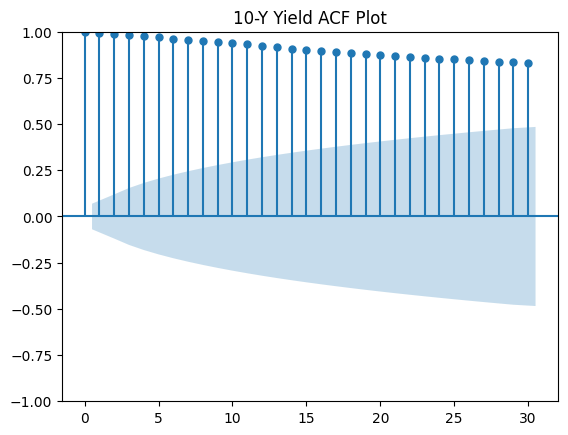

In [199]:
# Autocorrelation Function
# This is used to determine the appropriate lag
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# use the original data
series = df['GS10']
plot_acf(series, title = '10-Y Yield ACF Plot')
plt.show()
# Looks like even up to a lag of 10 could provide significant information about the ensuing years

In [202]:
# Split into training and test sets; since we are looking at time series; we are NOT randomly splitting the data
# Take instead the first 80% for the training, then we'll see if the first 80% of MLB history can be used to predict the next 20%
import numpy as np
strikeout = df[['sasdate', 'GS10']]
train_size = int(.8 * len(strikeout))
train_data = strikeout[:train_size]
test_data = strikeout[train_size:]

# put the y feature (the current SO9) in arrays
y_train = np.array(train_data['GS10']).reshape(-1,1)
y_test = np.array(test_data['GS10']).reshape(-1,1)

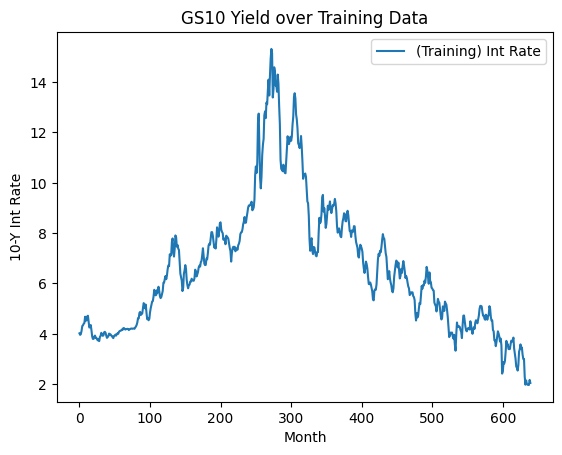

In [233]:
# visualize the time series
plt.plot(train_data['GS10'], label='(Training) Int Rate')
plt.xlabel('Month')
plt.ylabel('10-Y Int Rate')
plt.legend()
plt.title('GS10 Yield over Training Data')
plt.show()

In [206]:
df['GS10'].corr(df['GS10'].shift(30))

np.float64(0.8398874834165925)

In [225]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import AutoReg
from statsmodels.tsa.arima.model import ARIMA

ar_model = AutoReg(y_train, lags=30, trend='n') # the default is to add an intercept (or, trend='c'), 
ar_model = ARIMA(y_train, order=(30, 0, 1))
# using trend='n' is more in line with traditional AR(p) models, but may result in a nonstationary model
ar_results = ar_model.fit()

/Users/dylantoplas/.pyenv/versions/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [226]:
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data2 = pd.DataFrame({'Year': test_data.index, 'pred GS10': ar_pred.flatten()})
pred_data2.set_index('Year', inplace = True)
pred_data2.head()

,pred GS10
Year,
640,1.965956
641,2.040306
642,1.932418
643,1.943323
644,1.945525


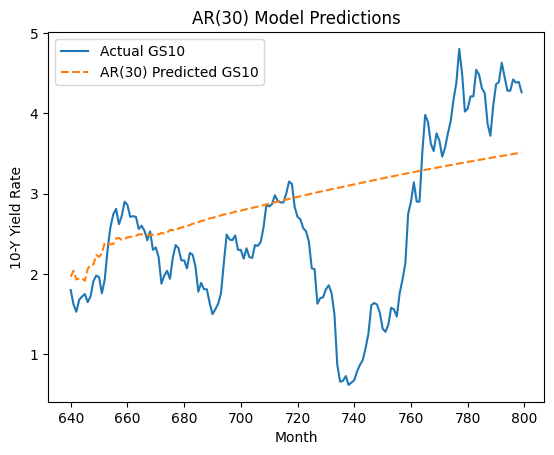

In [230]:
# make the plot
plt.plot(test_data['GS10'], label = 'Actual GS10')
plt.plot(pred_data2['pred GS10'], label = 'AR(30) Predicted GS10', linestyle = '--')
plt.xlabel('Month')
plt.ylabel('10-Y Yield Rate')
plt.legend()
plt.title('AR(30) Model Predictions')
plt.show();

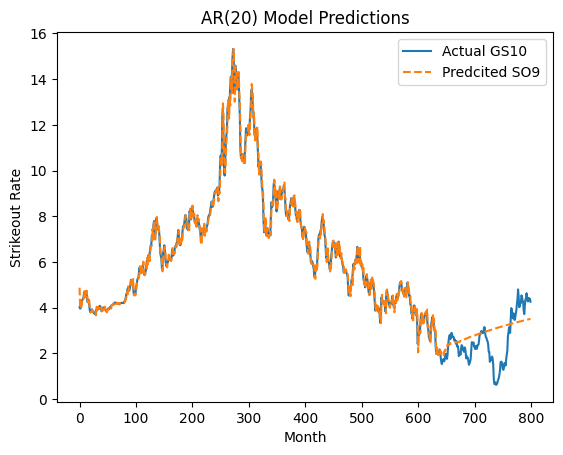

In [229]:
ar_pred_full = ar_results.predict(start=0, end=len(train_data) + len(test_data) - 1) # note we start at zero

plt.plot(df['GS10'], label = 'Actual GS10')
plt.plot(strikeout.index, ar_pred_full, label = 'Predcited SO9', linestyle = '--')
plt.xlabel('Month')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(20) Model Predictions')
plt.show();

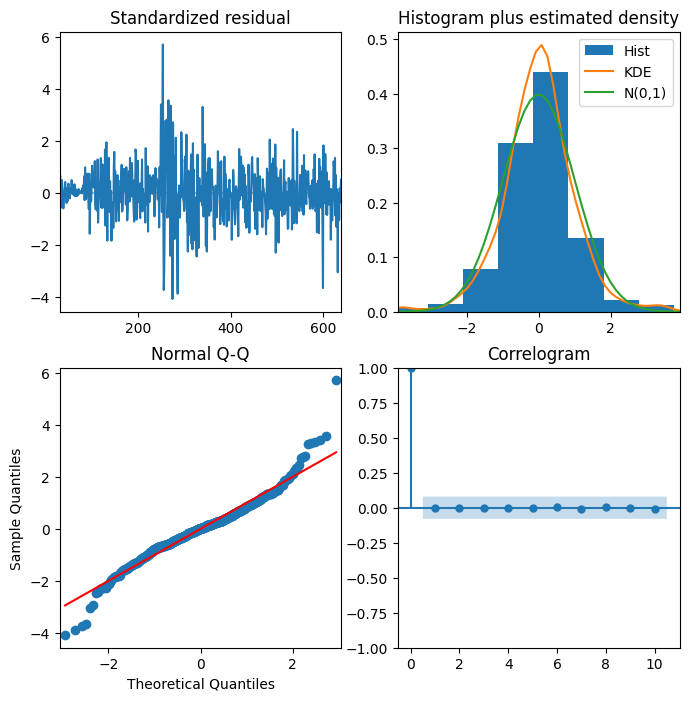

In [219]:
ar_results.plot_diagnostics(figsize=(8,8));

In [ ]:
combined_df = df.merge(
    auction_features,
    left_on='year_month',
    right_on='record_date',
    how='inner'
)

# Step 4: Clean up
combined_df = combined_df.drop('record_date', axis=1)
combined_df = combined_df.reset_index(drop=True)

In [ ]:
combined_df = combined_df.reset_index(drop=True)
combined_df = combined_df.loc[:, ~combined_df.columns.str.contains('^level_|^index$')]

In [ ]:
from dotenv import load_dotenv
from fredapi import Fred
import re, os

load_dotenv(override=True)
FRED_KEY = os.getenv('FRED_KEY')
fred = Fred(api_key=FRED_KEY)

def fetch_treasury_rates():
        """Fetch current Treasury zero rates from FRED"""
        series_ids = {
            # 1: "DGS1",     # 1-Year Treasury
            2: "DGS2",     # 2-Year Treasury  
            # 5: "DGS5",     # 5-Year Treasury
            # 10: "DGS10",   # 10-Year Treasury
            # 30: "DGS30"    # 30-Year Treasury
        }
        try:
            df = pd.DataFrame({m: fred.get_series(sid) for m, sid in series_ids.items()})
            latest_rates = df.iloc[-1].dropna()  
        except Exception as e:
            print(f"FRED API failed: {e}")
        
        return df

dgs2 = fetch_treasury_rates().loc['2018-01-01':'2025-10-31']

In [ ]:
dgs2 = dgs2.reset_index()
dgs2.columns = ['date', 'DGS2']  
dgs2['year_month'] = pd.to_datetime(dgs2['date']).dt.to_period('M')
dgs2 = dgs2.groupby('year_month').agg({
    'DGS2': 'mean'  # or 'last' for end-of-month values
}).reset_index()

dgs2

In [ ]:
combined_df = combined_df.merge(
    dgs2,  # Only keep date and value
    on='year_month',  # Merge on matching column name
    how='inner'
)

In [ ]:
combined_df

In [ ]:
macro_features = combined_df[[
    'FEDFUNDS',   # Current policy rate
    'CPIAUCSL',   # Inflation
    'INDPRO',     # Industrial production
    'UNRATE',     # Unemployment
    'M2SL',       # Money supply
    'S&P 500',    # Equity market
]]

# Add yield curve features (current state)
yield_features = pd.DataFrame({
    'current_10y': combined_df['GS10'],
    'current_2y': combined_df['DGS2'],
    '10y_2y_spread': combined_df['GS10'] - combined_df['DGS2'],  # Curve slope
    'yield_volatility': combined_df['GS10'].rolling(3).std(),  # Recent volatility
})

# Combine
X = pd.concat([
    macro_features,
    auction_features,
    yield_features
], axis=1)

# Target: next month's 10Y yield change
y = combined_df['GS10'].shift(-1) - combined_df['GS10']


In [ ]:
# pd.set_option('display.max_columns', None)
mask = X.columns != 'record_date'
correlation_matrix = X.iloc[7:-10, :].loc[:, mask].corr()
plt.figure(figsize=(16, 6)) # Optional: Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()
# pd.reset_option('display.max_columns')

In [235]:
X.tail(10)

,FEDFUNDS,CPIAUCSL,INDPRO,UNRATE,M2SL,S&P 500,bid_cover_bills,bid_cover_long,foreign_pct_bills,foreign_pct_long,dealer_pct_bills,dealer_pct_long,offering_bills_ma_ratio,current_10y,current_2y,10y_2y_spread,yield_volatility
79,5.33,314.131,103.0196,4.2,21185.3,5478.21,2.920714,2.526000,0.565050,0.683172,0.392218,0.129030,1.053192,3.87,3.965455,-0.095455,0.238607
80,5.13,314.851,102.5954,4.1,21272.2,5621.26,2.840357,2.445000,0.588163,0.690740,0.370121,0.145142,1.083114,3.72,3.622500,0.097500,0.273191
81,4.83,315.564,102.2138,4.1,21323.6,5792.32,2.822000,2.443333,0.542638,0.673181,0.407538,0.151116,1.034718,4.10,3.972273,0.127727,0.191398
82,4.64,316.449,101.9503,4.2,21424.5,5929.92,2.908214,2.580000,0.574811,0.661228,0.362941,0.178880,0.932848,4.36,4.257368,0.102632,0.321870
83,4.48,317.603,103.0447,4.1,21441.8,6010.91,2.903929,2.435000,0.574799,0.668953,0.360408,0.144496,0.969782,4.39,4.225714,0.164286,0.159478
84,4.33,319.086,102.8805,4.0,21510.9,5979.52,2.922800,2.580000,0.576096,0.723999,0.369445,0.123487,0.919012,4.63,4.271905,0.358095,0.147986
85,4.33,319.775,103.8705,4.1,21584.2,6038.69,2.856429,2.536000,0.573924,0.688101,0.370098,0.107125,1.018418,4.45,4.210000,0.240000,0.124900
86,4.33,319.615,103.5408,4.2,21656.9,5683.98,2.901379,2.413333,0.600768,0.670986,0.346866,0.171422,1.041390,4.28,3.970000,0.310000,0.175024
87,4.33,320.321,103.6224,4.2,21805.1,5369.50,2.927200,2.502000,0.599700,0.717977,0.342817,0.117145,1.001834,4.28,3.777619,0.502381,0.098150
88,4.33,320.580,103.6570,4.2,21884.6,5810.92,2.906875,2.523333,0.620707,0.767696,0.328701,0.134973,1.079014,4.42,3.920000,0.500000,0.080829


In [ ]:
y

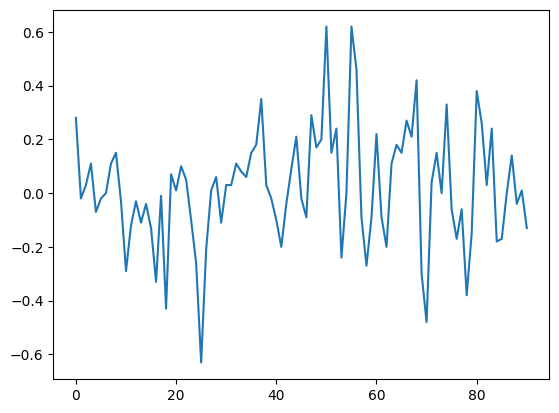

In [238]:
import matplotlib.pyplot as plt

plt.plot(y)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Prepare data
# Drop rows with NaN values
mask = X.columns != 'record_date'
X = X.iloc[7:-10, :].loc[:, mask]

X_clean = X.dropna()
y_clean = y.loc[X_clean.index].dropna()

# Align X and y
common_idx = X_clean.index.intersection(y_clean.index)
X_clean = X_clean.loc[common_idx]
y_clean = y_clean.loc[common_idx]

# Convert to numpy
X_arr = X_clean.values.astype(np.float32)
y_arr = y_clean.values.astype(np.float32)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build simple neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Regression output
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"\nTest MAE: {test_mae:.4f}")
print(f"Test MSE: {test_loss:.4f}")

# Make predictions
predictions = model.predict(X_test_scaled)

In [ ]:
a = np.array(y_test).reshape(-1, 1) - np.array(predictions).reshape(-1, 1)
print(a)

In [ ]:
plt.plot(predictions)
plt.plot(y_test, 'r-')
plt.xlabel('Predicted Values')  # Add parentheses and label text
plt.ylabel('Actual Values')     # Add y-axis label
plt.title('Predictions vs Actual')
  # Optional: add a title
plt.show()

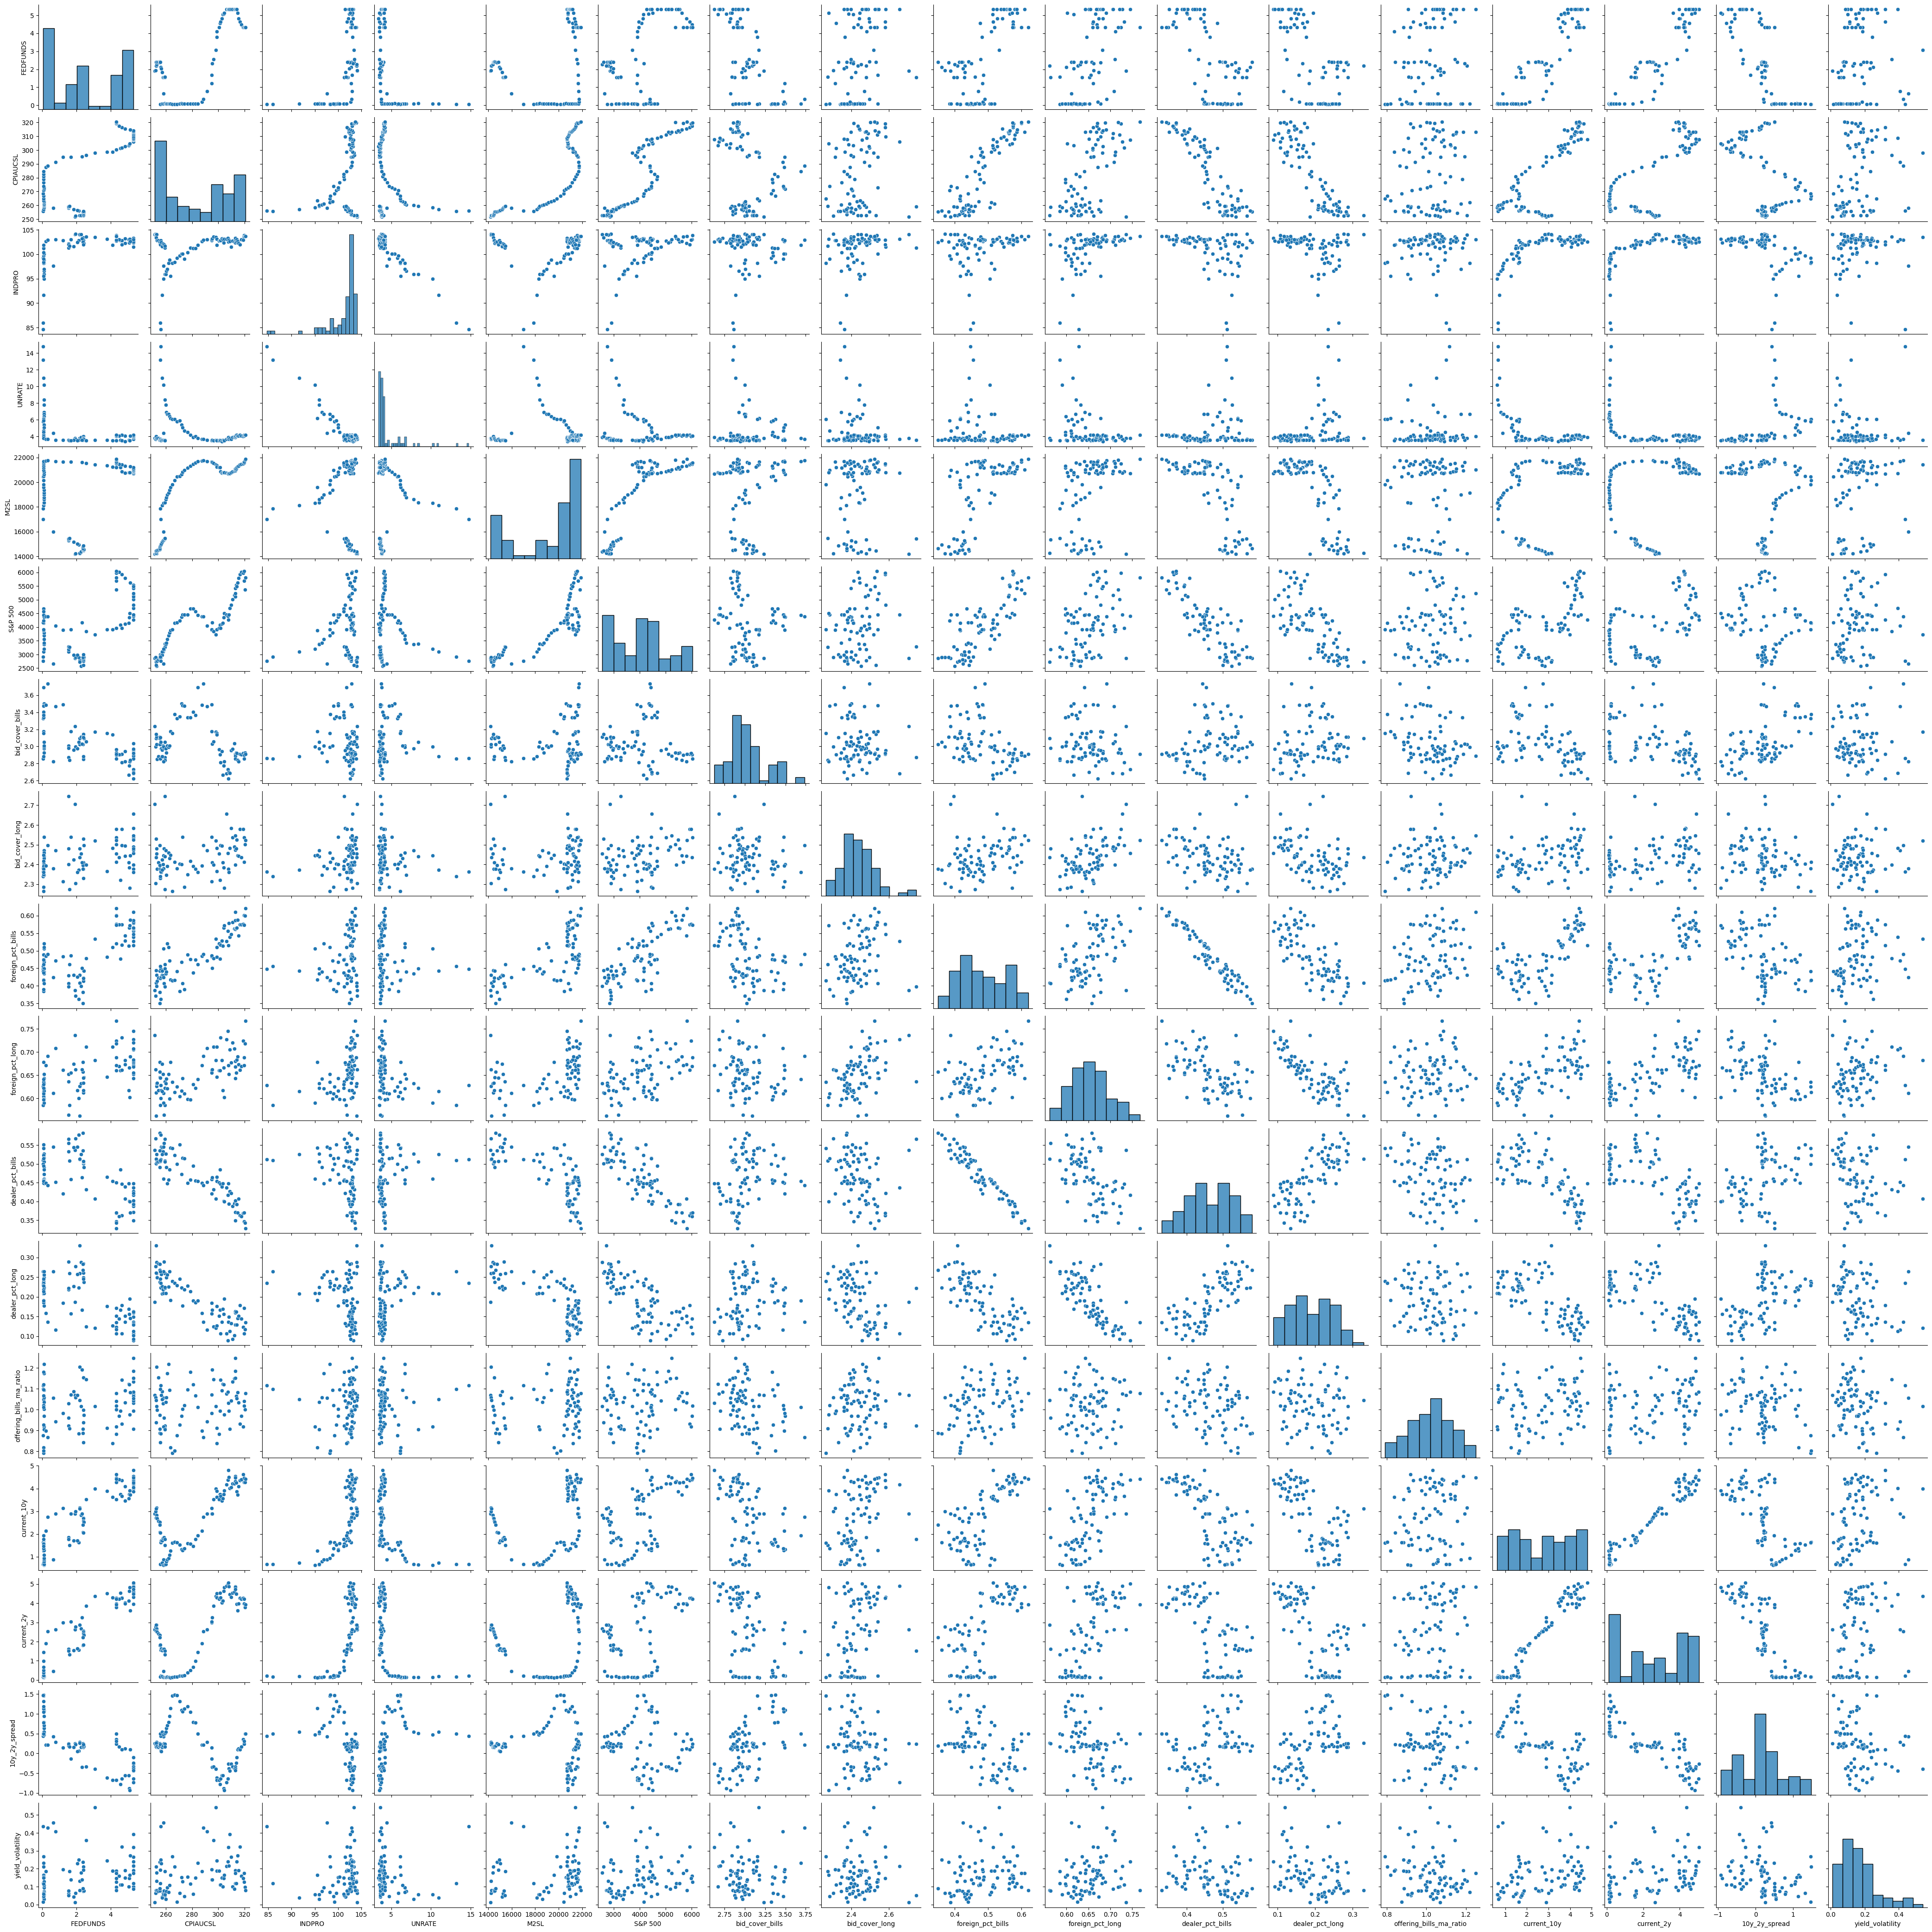

In [239]:
sns.pairplot(X)